# XGBoost Classification

## Imports

In [156]:
import pandas as pd
import numpy as np
from scipy.stats import uniform, randint

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    auc,
    balanced_accuracy_score,
    classification_report,
    roc_curve,
    RocCurveDisplay,
    accuracy_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.metrics import precision_recall_curve, f1_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, plot_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt


## Load Dataset

In [157]:
# Load and clean dataset
na_values = ["", " ", "NA", "N/A", "NULL"]
data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)
display(data.head(30))

threshold = 0.625
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = True
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)

# Auto-convert object columns that look numeric (e.g., 'Alter_0')
object_cols = data.select_dtypes(include="object").columns
numeric_like_cols = []
for col in object_cols:
    cleaned = (
        data[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    numeric_series = pd.to_numeric(cleaned, errors="coerce")
    if numeric_series.notna().mean() > 0.95:
        data[col] = numeric_series
        numeric_like_cols.append(col)

print(
    f"Converted {len(numeric_like_cols)} mostly-numeric columns: {numeric_like_cols}"
)
print(f"Cleaned dataset shape: {data.shape}")


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_7148/4168125254.py:3: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("T49.2_Sep2025_1_StGallen.csv", sep=";", na_values=na_values)


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,"56,9691991786448",0,112,",982456140350877","32,8731097961867",0,130.0,80.0,50.0,...,"9,44","4,38","3,99","14,1","25,8","7,8","3,99","3,99","3,99","3,99"
1,2,"69,4976043805613",0,104,"1,04","30,1102788964583",0,160.0,70.0,90.0,...,"19,8","8,97","7,75","21,9","41,3","20,1","7,35",NaN,"7,45","8,11"
2,2,"72,0492813141684",0,129,",941605839416058","44,7348800491207",0,140.0,90.0,50.0,...,"13,9","4,75","3,99","20,3","52,4","18,6","3,99","3,99","3,99","3,99"
3,2,"70,8145106091718",0,99,",876106194690266","26,2595847484332",0,130.0,90.0,40.0,...,20,"8,73","7,85","25,3","50,7",17,0,NaN,"7,63","9,02"
4,2,"62,1601642710472",1,125,NaN,"42,4366343891054",1,180.0,100.0,80.0,...,"16,9","9,14","8,3","29,5",43,"17,9","8,13",0,"8,4","8,51"
5,2,"73,82340862423",1,97,",989795918367347","26,4462809917355",0,157.0,85.0,72.0,...,"13,1",8,"7,4","15,1","26,4","15,2","7,4","3,89","7,53","8,15"
6,2,"58,4284736481862",1,92,",978723404255319","25,78125",1,130.0,85.0,45.0,...,"16,5","8,61",0,"21,5",48,"20,4",0,NaN,"7,71","9,31"
7,2,"54,5954825462012",0,NaN,NaN,"32,4661454995942",1,140.0,80.0,60.0,...,"18,7","8,84","8,54","28,2","42,7","15,9","8,28",0,"8,44","8,83"
8,2,"76,1724845995893",0,92,",884615384615385","27,2392244832559",0,150.0,110.0,40.0,...,"18,8","8,84","7,71","18,6","40,4","20,8","7,03",0,"7,77","8,3"
9,2,"46,7953456536619",1,81,",931034482758621","20,8209399167162",1,110.0,70.0,40.0,...,"9,25","4,13","3,99","15,7","39,9","14,5","3,99","3,99","3,99","3,99"


Converted 6 mostly-numeric columns: ['Alter_0', 'BMI_0', 'hba1c0', 'TyG_Index_neu', 'crp0', 'Kreat0']
Cleaned dataset shape: (1678, 94)


## Dropping dependant Features

In [158]:
columns_to_drop = ["remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol", "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"]
data = data.drop(columns_to_drop, axis=1)
print(list(data.columns))

['OUTCOME_3Kat_KHK', 'Alter_0', 'geschlecht', 'waist_0', 'WHR_0', 'BMI_0', 'currsmo0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'insulm0', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'diabetes_ADA_final_0', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'Kalium0', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'Cer_d18_16', 'Cer_d18_18', 'Cer_d

## Preprocessing

In [159]:
# Split data into features and target
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"].replace({2: 1})

manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
    ]
resolved_categoricals = []
missing_manual = []
for candidate in manual_categorical_candidates:
    match = next((col for col in X.columns if col.lower() == candidate.lower()), None)
    if match:
        resolved_categoricals.append(match)
    else:
        missing_manual.append(candidate)
if missing_manual:
    print(f"Manual categorical columns not found: {missing_manual}")

categorical_features = sorted(dict.fromkeys(resolved_categoricals))

non_cat_object_cols = [
    col for col in X.columns if col not in categorical_features and X[col].dtype == "object"
]
forced_numeric = []
for col in non_cat_object_cols:
    cleaned = (
        X[col]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.replace(",", ".", regex=False)
    )
    converted = pd.to_numeric(cleaned, errors="coerce")
    X[col] = converted
    forced_numeric.append(col)
if forced_numeric:
    sample = forced_numeric[:5]
    print(
        f"Forced {len(forced_numeric)} object columns to numeric (sample: {sample})"
    )


numerical_features = [col for col in X.columns if col not in categorical_features]

if categorical_features:
    X[categorical_features] = X[categorical_features].astype(str)

print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): sample -> {numerical_features[:5]}")

# Note: Features with >75% missing were already removed in Cell 4
# (data = data.loc[:, data.isnull().mean() < 0.75])

# Remove highly correlated numerical features
if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerische Features: {len(numerical_features)}")
print(f"After cleaning - Kategoriale Features: {len(categorical_features)}")

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cat_pre = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", SimpleImputer(strategy="median"), numerical_features),
    ]
)


Forced 48 object columns to numeric (sample: ['waist_0', 'WHR_0', 'Lp_a_0', 'insulm0', 'HOMA_Index_IR_0'])
Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (79): sample -> ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0']
Removing 1 highly correlated features
After cleaning - Numerische Features: 78
After cleaning - Kategoriale Features: 7


## Build Pipeline

In [160]:
# Set random seeds for reproducibility (if not already set)
np.random.seed(42)

# Feature selection BEFORE pipeline (more stable for CV)
# Fit preprocessor and select features on full training set
temp_preprocessor = preprocessor.fit(X_train, y_train)
X_train_transformed = temp_preprocessor.transform(X_train)
X_test_transformed = temp_preprocessor.transform(X_test)

# Select features based on full training set (top 50 for binary problem)
selector = SelectKBest(mutual_info_classif, k=50)
X_train_selected = selector.fit_transform(X_train_transformed, y_train)
X_test_selected = selector.transform(X_test_transformed)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

# Calculate scale_pos_weight to favor recall for Significant Stenosis (class 1)
# CRITICAL FIX: We need to INVERT the calculation because class 1 is the MAJORITY, not minority!
# In XGBoost, scale_pos_weight > 1.0 favors the positive class (class 1)
# Since class 1 (Significant Stenosis) is the majority, we invert: class_counts[1] / class_counts[0]
class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution - Class 0 (No Stenosis): {class_counts[0]}, Class 1 (Significant Stenosis): {class_counts[1]}")

# CORRECTED: Invert to favor class 1 (which is the majority)
# Base ratio: majority / minority = class 1 / class 0
base_ratio = class_counts[1] / class_counts[0]  # 1036 / 306 ≈ 3.39

# Since SMOTE already balances classes, use moderate multiplier to give preference to class 1
# Without SMOTE, we'd use base_ratio directly, but with SMOTE we moderate it to avoid over-weighting
scale_pos_weight_multiplier = 0.4  # REVERTED: Back to working state
scale_pos_weight = base_ratio * scale_pos_weight_multiplier

print(f"Base ratio (class 1 / class 0): {base_ratio:.2f}")
print(f"Multiplier (accounts for SMOTE): {scale_pos_weight_multiplier}")
print(f"Final scale_pos_weight: {scale_pos_weight:.2f} (favors class 1 - Significant Stenosis)")
print(f"  → XGBoost will weight class 1 samples {scale_pos_weight:.2f}x more than class 0")
print(f"  → This should increase recall for Significant Stenosis (class 1)")

# Pipeline with SMOTE and regularized XGBoost optimized for high recall of class 1
pipeline = Pipeline(
    [
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=200,        # REVERTED: Back to working state
            learning_rate=0.01,      # Slower learning to prevent overfitting
            max_depth=3,             # Shallower trees (reduced from 6)
            min_child_weight=5,      # REVERTED: Back to working state
            subsample=0.8,           # Row subsampling
            colsample_bytree=0.7,    # Column subsampling
            reg_lambda=3.0,          # REVERTED: Back to working state
            reg_alpha=1.5,           # L1 regularization
            scale_pos_weight=scale_pos_weight,  # Favor recall for class 1
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )),
    ]
)

# CV and training on selected features
# Perform 5-fold cross-validation with balanced accuracy
# IMPORTANT: Use StratifiedKFold with random_state for reproducible results
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train_selected, y_train, cv=cv_strategy, scoring='balanced_accuracy')

# Fit the model on the training data
pipeline.fit(X_train_selected, y_train)

# Predict on the test set (using selected features)
y_pred = pipeline.predict(X_test_selected)
y_proba = pipeline.predict_proba(X_test_selected)




Selected 50 features out of 96
Class distribution - Class 0 (No Stenosis): 306, Class 1 (Significant Stenosis): 1036
Base ratio (class 1 / class 0): 3.39
Multiplier (accounts for SMOTE): 0.4
Final scale_pos_weight: 1.35 (favors class 1 - Significant Stenosis)
  → XGBoost will weight class 1 samples 1.35x more than class 0
  → This should increase recall for Significant Stenosis (class 1)


## Evaluation

In [161]:

# Classification Report
from sklearn.metrics import recall_score

report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Significant Stenosis"])

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Recall for Significant Stenosis (Class 1) - MOST IMPORTANT METRIC
recall_class1 = recall_score(y_test, y_pred, pos_label=1)

print("=" * 80)
print("MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\n⭐ Test Recall (Significant Stenosis): {recall_class1:.4f} ⭐")
print(f"Test Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f}")
print("\nClassification Report:")
print(report)


MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 1)

⭐ Test Recall (Significant Stenosis): 0.8746 ⭐
Test Balanced Accuracy: 0.6829
Mean Cross-Validation Balanced Accuracy: 0.6937

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.44      0.49      0.47        57
Significant Stenosis       0.89      0.87      0.88       279

            accuracy                           0.81       336
           macro avg       0.67      0.68      0.68       336
        weighted avg       0.82      0.81      0.81       336



In [122]:
# Overfitting Check - Focus on Recall for Significant Stenosis (Class 1)
from sklearn.metrics import balanced_accuracy_score, accuracy_score, recall_score

# Predictions on training and test sets
y_pred_train = pipeline.predict(X_train_selected)
y_pred_test = y_pred  # Already computed

# Calculate recall for class 1 (Significant Stenosis) - MOST IMPORTANT
train_recall_class1 = recall_score(y_train, y_pred_train, pos_label=1)
test_recall_class1 = recall_score(y_test, y_pred_test, pos_label=1)

# Calculate balanced accuracy for both
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

# Calculate regular accuracy for both
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)")
print("=" * 80)
print(f"\n⭐ Recall (Significant Stenosis) ⭐")
print(f"  Training: {train_recall_class1:.4f}")
print(f"  Test:     {test_recall_class1:.4f}")
print(f"  Gap:      {train_recall_class1 - test_recall_class1:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

# Warning if gap is too large (check both recall and balanced accuracy)
gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("⚠️  WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("⚠️  CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("✓ Model shows good generalization (small gap between train/test)")
    print(f"  ✓ Recall gap: {gap_recall:.4f} (good)")
    print(f"  ✓ Balanced accuracy gap: {gap_bal:.4f} (good)")



OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 1)

⭐ Recall (Significant Stenosis) ⭐
  Training: 0.8842
  Test:     0.8746
  Gap:      0.0096

Balanced Accuracy:
  Training: 0.7313
  Test:     0.6829
  Gap:      0.0484

Regular Accuracy:
  Training: 0.8145
  Test:     0.8095
  Gap:      0.0049

✓ Model shows good generalization (small gap between train/test)
  ✓ Recall gap: 0.0096 (good)
  ✓ Balanced accuracy gap: 0.0484 (good)


## Threshold Optimization


Testing thresholds to maximize Recall for Significant Stenosis (Class 1)...

✓ Found threshold meeting targets (Class 1 recall >= 0.75, Class 0 recall >= 0.65)
  → Selected threshold with HIGHEST BALANCED ACCURACY among candidates

Optimal threshold: 0.6000
Training - Recall (Class 1 - Significant Stenosis): 0.7867
Training - Recall (Class 0 - No Stenosis): 0.7549
Training - Balanced Accuracy: 0.7708

Test - Recall (Class 1 - Significant Stenosis): 0.7527 ⭐
Test - Recall (Class 0 - No Stenosis): 0.6667
Test - Balanced Accuracy: 0.7097

=== Results with Optimal Threshold (0.6000) ===
Test Balanced Accuracy: 0.7097
Test Recall (Significant Stenosis): 0.7527 ⭐
Test Precision (Significant Stenosis): 0.9170

Classification Report:
                      precision    recall  f1-score   support

         No Stenosis       0.36      0.67      0.46        57
Significant Stenosis       0.92      0.75      0.83       279

            accuracy                           0.74       336
           mac

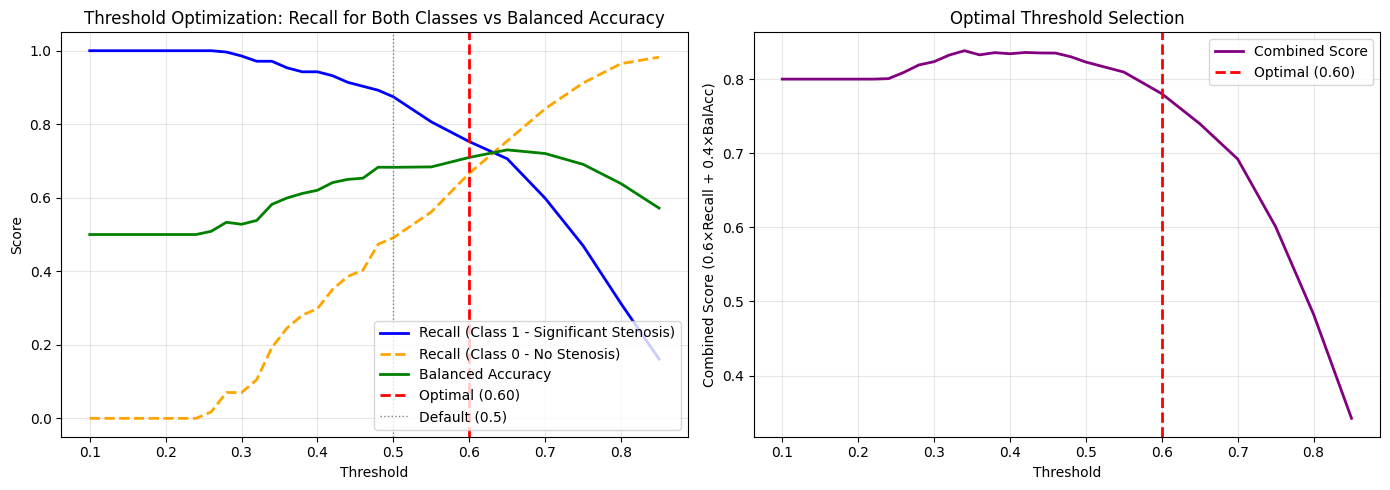

In [155]:
# OPTIMIZE THRESHOLD: Maximize Recall for Significant Stenosis (Class 1) 
# while maintaining good balanced accuracy and preventing overfitting
# IMPORTANT: Lower threshold = MORE predictions of class 1 = HIGHER recall for Significant Stenosis
# Currently model is too conservative (recall for class 1 is only 43%, should be ~90%+)
# We need to LOWER the threshold significantly (target: 0.2-0.4 instead of 0.5)

from sklearn.metrics import recall_score, precision_score

# Get probability predictions
y_proba_train = pipeline.predict_proba(X_train_selected)[:, 1]
y_proba_test = pipeline.predict_proba(X_test_selected)[:, 1]

# Test different thresholds to find optimal balance
# LOWER thresholds = MORE predictions of class 1 = HIGHER recall for Significant Stenosis
# We want to test lower thresholds (0.1-0.5) more thoroughly since we need high recall for class 1
thresholds_to_test = np.concatenate([
    np.arange(0.1, 0.5, 0.02),  # Fine-grained for lower thresholds (where we want to be)
    np.arange(0.5, 0.9, 0.05)   # Coarser for higher thresholds
])
results = []

print("Testing thresholds to maximize Recall for Significant Stenosis (Class 1)...")
print("=" * 80)

for thresh in thresholds_to_test:
    y_pred_thresh = (y_proba_train >= thresh).astype(int)
    
    # Calculate metrics on training set
    recall_class1_train = recall_score(y_train, y_pred_thresh, pos_label=1)  # Recall for Significant Stenosis
    recall_class0_train = recall_score(y_train, y_pred_thresh, pos_label=0)  # Recall for No Stenosis
    bal_acc_train = balanced_accuracy_score(y_train, y_pred_thresh)
    
    # Calculate on test set (for comparison, but we'll choose based on train to avoid overfitting)
    y_pred_thresh_test = (y_proba_test >= thresh).astype(int)
    recall_class1_test = recall_score(y_test, y_pred_thresh_test, pos_label=1)
    recall_class0_test = recall_score(y_test, y_pred_thresh_test, pos_label=0)
    bal_acc_test = balanced_accuracy_score(y_test, y_pred_thresh_test)
    
    # Combined score: Prioritize recall for class 1, but also maintain reasonable recall for class 0
    # REVERTED: Back to working state - 70% class 1 recall, 20% balanced accuracy, 10% class 0 recall
    combined_score = recall_class1_train * 0.7 + bal_acc_train * 0.2 + recall_class0_train * 0.1
    
    results.append({
        'threshold': thresh,
        'recall_class1_train': recall_class1_train,
        'recall_class0_train': recall_class0_train,
        'bal_acc_train': bal_acc_train,
        'recall_class1_test': recall_class1_test,
        'recall_class0_test': recall_class0_test,
        'bal_acc_test': bal_acc_test,
        'combined_score': combined_score
    })

results_df = pd.DataFrame(results)

# Strategy: Find threshold that balances recall for both classes while prioritizing class 1
# REVERTED: Back to working state
target_recall_class1 = 0.75
target_recall_class0 = 0.65

candidates = results_df[
    (results_df['recall_class1_train'] >= target_recall_class1) & 
    (results_df['recall_class0_train'] >= target_recall_class0)
]

if len(candidates) > 0:
    # OPTIMIZED: Among candidates, directly maximize balanced accuracy (this is what we want to improve!)
    # This ensures we get the best balanced accuracy while maintaining minimum recall for class 1
    optimal_idx = candidates['bal_acc_train'].idxmax()
    optimal_threshold = results_df.loc[optimal_idx, 'threshold']
    print(f"\n✓ Found threshold meeting targets (Class 1 recall >= {target_recall_class1}, Class 0 recall >= {target_recall_class0})")
    print(f"  → Selected threshold with HIGHEST BALANCED ACCURACY among candidates")
else:
    # Fallback: Find threshold that maximizes balanced accuracy while ensuring class 1 recall >= 0.70
    min_class1_recall = 0.70
    candidates_fallback = results_df[results_df['recall_class1_train'] >= min_class1_recall]
    if len(candidates_fallback) > 0:
        optimal_idx = candidates_fallback['bal_acc_train'].idxmax()
        optimal_threshold = results_df.loc[optimal_idx, 'threshold']
        print(f"\n⚠ No threshold meets both targets, but found threshold with class 1 recall >= {min_class1_recall}")
        print(f"  → Selected threshold with HIGHEST BALANCED ACCURACY (class 1 recall >= {min_class1_recall})")
    else:
        # Last resort: maximize balanced accuracy directly
        optimal_idx = results_df['bal_acc_train'].idxmax()
        optimal_threshold = results_df.loc[optimal_idx, 'threshold']
        print(f"\n⚠ Using threshold with highest balanced accuracy (may not meet recall targets)")

print(f"\nOptimal threshold: {optimal_threshold:.4f}")
print(f"Training - Recall (Class 1 - Significant Stenosis): {results_df.loc[optimal_idx, 'recall_class1_train']:.4f}")
print(f"Training - Recall (Class 0 - No Stenosis): {results_df.loc[optimal_idx, 'recall_class0_train']:.4f}")
print(f"Training - Balanced Accuracy: {results_df.loc[optimal_idx, 'bal_acc_train']:.4f}")
print(f"\nTest - Recall (Class 1 - Significant Stenosis): {results_df.loc[optimal_idx, 'recall_class1_test']:.4f} ⭐")
print(f"Test - Recall (Class 0 - No Stenosis): {results_df.loc[optimal_idx, 'recall_class0_test']:.4f}")
print(f"Test - Balanced Accuracy: {results_df.loc[optimal_idx, 'bal_acc_test']:.4f}")

# Apply optimal threshold
y_pred_optimal = (y_proba_test >= optimal_threshold).astype(int)

# Detailed evaluation
print(f"\n=== Results with Optimal Threshold ({optimal_threshold:.4f}) ===")
bal_acc_optimal = balanced_accuracy_score(y_test, y_pred_optimal)
recall_class1_optimal = recall_score(y_test, y_pred_optimal, pos_label=1)
precision_class1_optimal = precision_score(y_test, y_pred_optimal, pos_label=1)

print(f"Test Balanced Accuracy: {bal_acc_optimal:.4f}")
print(f"Test Recall (Significant Stenosis): {recall_class1_optimal:.4f} ⭐")
print(f"Test Precision (Significant Stenosis): {precision_class1_optimal:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=["No Stenosis", "Significant Stenosis"]))

# Compare with default threshold
print(f"\n=== Comparison ===")
recall_class1_default = recall_score(y_test, y_pred, pos_label=1)
recall_class0_default = recall_score(y_test, y_pred, pos_label=0)
print(f"Default threshold (0.5):")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"  Recall (Class 1 - Significant Stenosis): {recall_class1_default:.4f}")
print(f"  Recall (Class 0 - No Stenosis): {recall_class0_default:.4f}")
print(f"\nOptimal threshold ({optimal_threshold:.4f}):")
print(f"  Balanced Accuracy: {bal_acc_optimal:.4f}")
print(f"  Recall (Class 1 - Significant Stenosis): {recall_class1_optimal:.4f} ⭐")
print(f"  Recall (Class 0 - No Stenosis): {recall_score(y_test, y_pred_optimal, pos_label=0):.4f}")
print(f"  Improvement in Recall (Class 1): {recall_class1_optimal - recall_class1_default:+.4f}")
print(f"  Change in Recall (Class 0): {recall_score(y_test, y_pred_optimal, pos_label=0) - recall_class0_default:+.4f}")

# Visualize threshold selection
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Recall for both classes and Balanced Accuracy vs Threshold
ax1.plot(results_df['threshold'], results_df['recall_class1_test'], 'b-', label='Recall (Class 1 - Significant Stenosis)', linewidth=2)
ax1.plot(results_df['threshold'], results_df['recall_class0_test'], 'orange', linestyle='--', label='Recall (Class 0 - No Stenosis)', linewidth=2)
ax1.plot(results_df['threshold'], results_df['bal_acc_test'], 'g-', label='Balanced Accuracy', linewidth=2)
ax1.axvline(x=optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal ({optimal_threshold:.2f})')
ax1.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, label='Default (0.5)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Threshold Optimization: Recall for Both Classes vs Balanced Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Combined Score
ax2.plot(results_df['threshold'], results_df['combined_score'], 'purple', linewidth=2, label='Combined Score')
ax2.axvline(x=optimal_threshold, color='r', linestyle='--', linewidth=2, label=f'Optimal ({optimal_threshold:.2f})')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Combined Score (0.6×Recall + 0.4×BalAcc)')
ax2.set_title('Optimal Threshold Selection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Visualization Binary

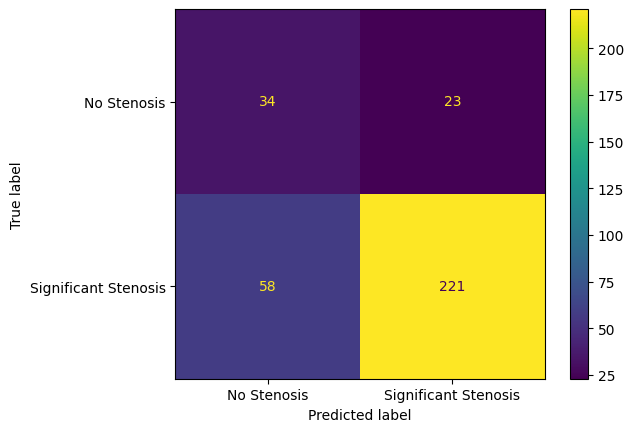

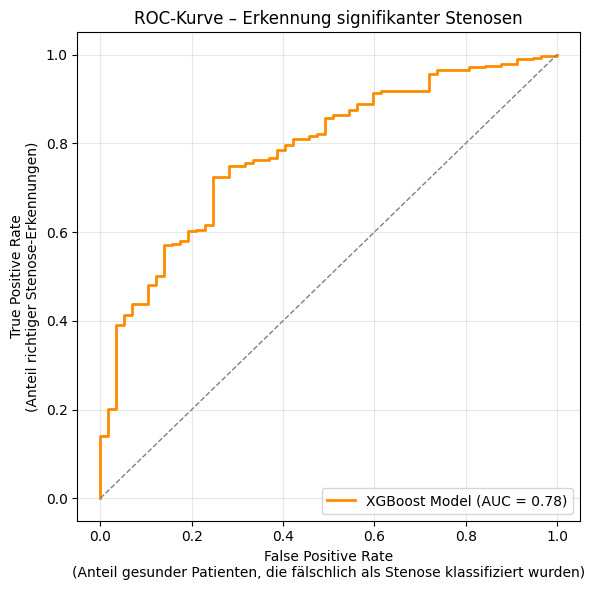

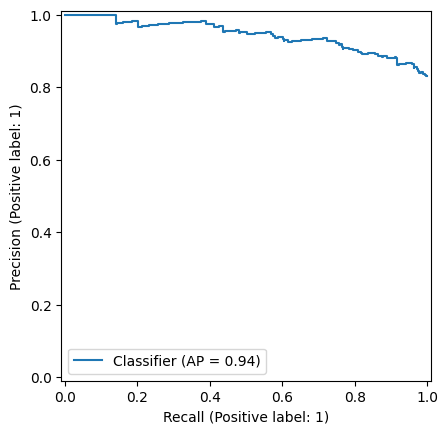

In [10]:

# Get preprocessed test data (already transformed and selected)
# X_test_selected was created in Cell 10
clf = pipeline.named_steps["classifier"]
y_pred = clf.predict(X_test_selected)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

# ROC Curve
y_prob = clf.predict_proba(X_test_selected)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

# Achsenbeschriftungen und Titel
plt.xlabel("False Positive Rate\n(Anteil gesunder Patienten, die fälschlich als Stenose klassifiziert wurden)")
plt.ylabel("True Positive Rate\n(Anteil richtiger Stenose-Erkennungen)")
plt.title("ROC-Kurve – Erkennung signifikanter Stenosen")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, clf.predict_proba(X_test_selected)[:, 1])


# Feature Importance

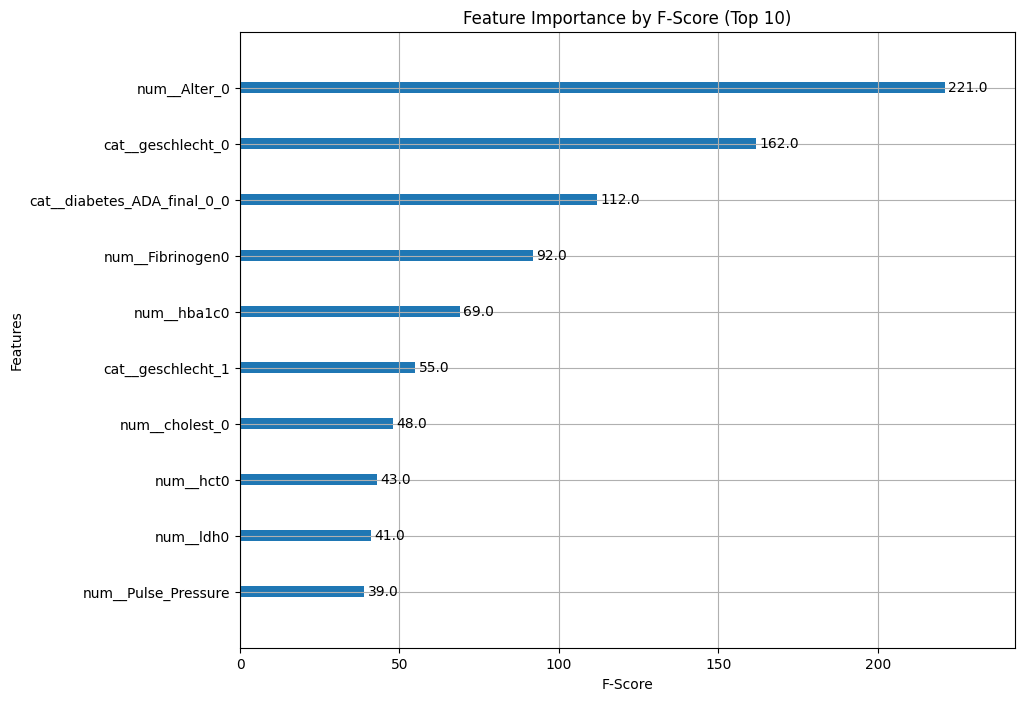

In [11]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get feature names from preprocessor and map to selected features
all_feature_names = temp_preprocessor.get_feature_names_out()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# 2. Extract the trained XGBoost model
xgb_model = pipeline.named_steps['classifier']

# 3. Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. Set the feature names on the Booster object (use selected feature names)
booster.feature_names = selected_feature_names

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

--- Worst 10 Features by F-Score Importance ---
                           Feature  Importance
44                      num__CERT2         1.0
43                    num__PC_38_5         1.0
42  num__Cer_d18_16_I_Cer_d18_24_0         2.0
32             num__GOT_GPT_Ratio0         2.0
18            num__MONOCYTE_gesamt         3.0
31                       num__got0         4.0
30                     num__Kreat0         4.0
21            num__NEUT_ABS_gesamt         4.0
37                       num__tsh0         4.0
36                       num__ptt0         5.0


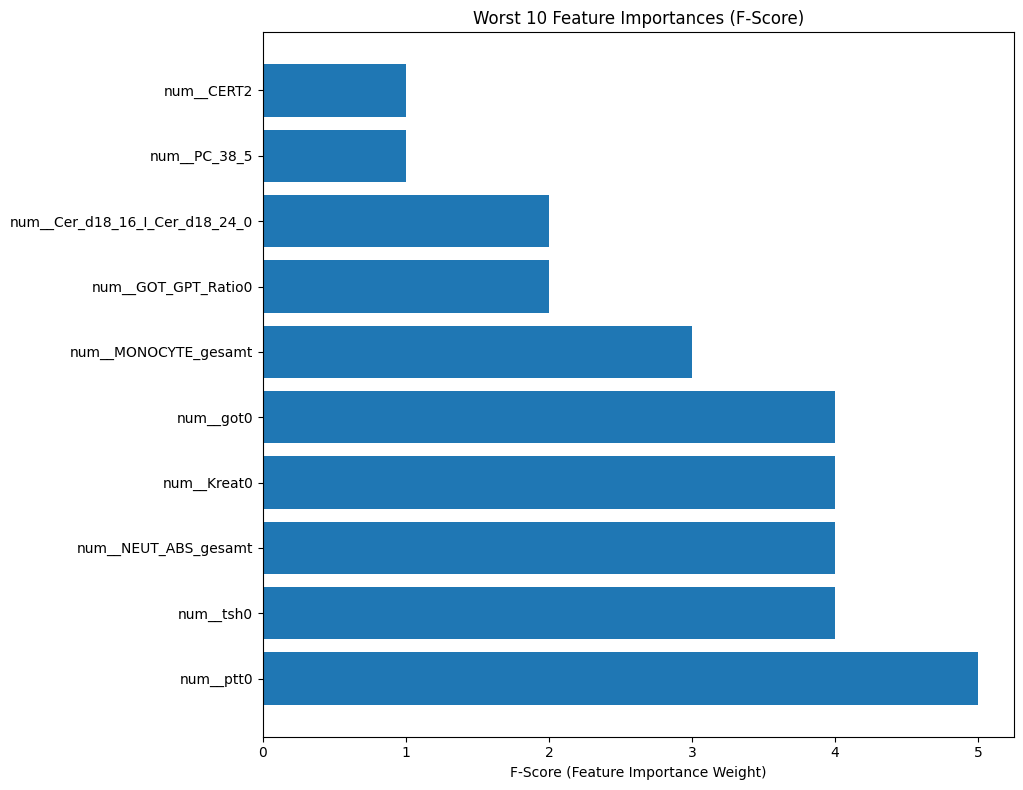

In [12]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
# Inspect how each feature is treated
feature_treatment = pd.DataFrame({
    'feature': X.columns,
    'pandas_dtype': X.dtypes.astype(str),
    'treated_as': [
        'categorical' if col in categorical_features else (
            'numerical' if col in numerical_features else 'other'
        )
        for col in X.columns
    ]
})
display(feature_treatment.sort_values(['treated_as', 'feature']).reset_index(drop=True))
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical features ({len(numerical_features)}): {numerical_features}")


,feature,pandas_dtype,treated_as
0,ANY_OPE,object,categorical
1,ANY_OPO,object,categorical
2,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,object,categorical
3,Osteoporose_T_Wert_abhängig,object,categorical
4,currsmo0,object,categorical
...,...,...,...
80,quick0,float64,numerical
81,remnantCholesterol0,float64,numerical
82,triglyc_0,float64,numerical
83,tsh0,float64,numerical


Categorical features (7): ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Numerical features (78): ['Alter_0', 'waist_0', 'WHR_0', 'BMI_0', 'RR_syst_0', 'RR_diast_0', 'Pulse_Pressure', 'LDL_0', 'HDL_0', 'triglyc_0', 'cholest_0', 'Lp_a_0', 'apo_A1_gesamt_0', 'apo_B_gesamt_0', 'remnantCholesterol0', 'Glucose_0', 'hba1c0', 'TyG_Index_neu', 'HOMA_Index_IR_0', 'Delta_Blutglucose', 'FLI', 'THROMB0_gesamt', 'NEUTROPH_gesamt', 'LYMPHOCY_gesamt', 'NLR', 'MONOCYTE_gesamt', 'EOSINOPH_gesamt', 'BASOPHIL_gesamt', 'NEUT_ABS_gesamt', 'LYMP_ABS_gesamt', 'leuko0', 'ery0', 'hb0', 'hct0', 'NATRIUM', 'Kalium0', 'eGFR_CKD_EPI_Kreatinin', 'Kreatinin_Harn_0', 'Albumin_Harn_0', 'BNP', 'Fibrinogen0', 'crp0', 'Harnstoff0', 'Kreat0', 'Cystatin_gesamt', 'got0', 'gpt0', 'GOT_GPT_Ratio0', 'ggt0', 'aph0', 'ldh0', 'cpk0', 'quick0', 'ptt0', 'tsh0', 'gesew0', 'GESAMT_B', 'GESAMT_T', 'GESAMT_A', 'APPLEAN', 'Cer_d18_16',

## Gridsearch

In [ ]:
# OPTIMIZED: RandomizedSearchCV prioritizing Recall for Significant Stenosis (Class 1)
# while maintaining good balanced accuracy and preventing overfitting

from sklearn.metrics import make_scorer, recall_score

# Custom scorer: Weighted combination prioritizing recall for class 1
# Slightly increased weight on recall (65% vs 60%) to improve recall while maintaining balance
def combined_recall_balanced_scorer(y_true, y_pred):
    """Combined scorer: 65% recall for class 1 + 35% balanced accuracy"""
    recall_class1 = recall_score(y_true, y_pred, pos_label=1)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return 0.65 * recall_class1 + 0.35 * bal_acc

custom_scorer = make_scorer(combined_recall_balanced_scorer)

# Parameter distributions - adjusted to favor higher recall
param_distributions = {
    'classifier__n_estimators': randint(150, 400),
    'classifier__max_depth': randint(2, 5),  # Shallower trees to prevent overfitting
    'classifier__learning_rate': uniform(0.01, 0.04),  # 0.01 to 0.05
    'classifier__subsample': uniform(0.7, 0.2),  # 0.7 to 0.9
    'classifier__colsample_bytree': uniform(0.6, 0.2),  # 0.6 to 0.8
    'classifier__min_child_weight': randint(1, 8),
    'classifier__reg_lambda': uniform(1.0, 4.0),  # 1.0 to 5.0
    'classifier__reg_alpha': uniform(0.5, 2.0),  # 0.5 to 2.5
    'classifier__scale_pos_weight': uniform(0.5, 1.5),  # 0.5 to 2.0 - Adjusted range based on actual class distribution
}

# Create pipeline with SMOTE
pipeline_for_search = Pipeline([
    ("smote", SMOTE(random_state=42, k_neighbors=3)),
    ("classifier", XGBClassifier(
        tree_method="hist",
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )),
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # More folds for better estimate

# RandomizedSearchCV with custom scorer prioritizing recall for class 1
random_search = RandomizedSearchCV(
    estimator=pipeline_for_search,
    param_distributions=param_distributions,
    n_iter=50,  # Try 50 random combinations
    scoring=custom_scorer,  # Custom scorer prioritizing recall for class 1
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

print("Starting RandomizedSearchCV...")
print("Objective: Maximize Recall for Significant Stenosis (Class 1) + Balanced Accuracy")
print("Scoring: 65% Recall(Class 1) + 35% Balanced Accuracy")
print("This will try 50 random parameter combinations")
random_search.fit(X_train_selected, y_train)

print(f"\nBest combined score (CV): {random_search.best_score_:.4f}")
print('Best params:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

best_model = random_search.best_estimator_

# Evaluate best model
y_pred_rs = best_model.predict(X_train_selected)
y_pred_rs_test = best_model.predict(X_test_selected)

# Calculate metrics
train_recall_class1 = recall_score(y_train, y_pred_rs, pos_label=1)
test_recall_class1 = recall_score(y_test, y_pred_rs_test, pos_label=1)
train_bal_acc = balanced_accuracy_score(y_train, y_pred_rs)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_rs_test)

print(f"\n=== Best Model Performance ===")
print(f"Training - Recall (Class 1): {train_recall_class1:.4f}")
print(f"Training - Balanced Accuracy: {train_bal_acc:.4f}")
print(f"Test - Recall (Class 1): {test_recall_class1:.4f} ⭐")
print(f"Test - Balanced Accuracy: {test_bal_acc:.4f}")
print(f"Overfitting gap (Recall): {train_recall_class1 - test_recall_class1:.4f}")
print(f"Overfitting gap (BalAcc): {train_bal_acc - test_bal_acc:.4f}")

# Check for overfitting
gap_recall = train_recall_class1 - test_recall_class1
gap_bal = train_bal_acc - test_bal_acc
if gap_recall > 0.15 or gap_bal > 0.15:
    print("\n⚠️  WARNING: Large gap detected - model may be overfitting!")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("\n⚠️  CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("\n✓ Model shows good generalization (small gap between train/test)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rs_test, target_names=["No Stenosis", "Significant Stenosis"]))


Fitting 3 folds for each of 2916 candidates, totalling 8748 fits


Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x1307acd70>>
Traceback (most recent call last):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 630, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 
Fatal Python error: Aborted

Current thread 0x00000001ee782080 (most recent call first):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 1823 in _init
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboost/core.py", line 1768 in __init__
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/xgboo

KeyboardInterrupt: 

## Feature Selection Optimization


In [ ]:
# Test different numbers of features to find optimal k
# This helps balance model complexity and performance

k_values = [30, 40, 50, 60, 70, 80]
results = []

print("Testing different feature selection k values...")
print("=" * 60)

for k in k_values:
    # Select k features
    selector_k = SelectKBest(mutual_info_classif, k=k)
    X_train_k = selector_k.fit_transform(X_train_transformed, y_train)
    X_test_k = selector_k.transform(X_test_transformed)
    
    # Quick evaluation with simple model (faster)
    temp_pipeline = Pipeline([
        ("smote", SMOTE(random_state=42, k_neighbors=3)),
        ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=100,
            learning_rate=0.01,
            max_depth=3,
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        )),
    ])
    
    # Quick CV (3 folds for speed) - Use StratifiedKFold with random_state for reproducibility
    cv_strategy_k = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores_k = cross_val_score(temp_pipeline, X_train_k, y_train, cv=cv_strategy_k, scoring='balanced_accuracy')
    
    results.append({
        'k': k,
        'cv_mean': cv_scores_k.mean(),
        'cv_std': cv_scores_k.std()
    })
    
    print(f"k={k:2d}: CV Balanced Accuracy = {cv_scores_k.mean():.4f} (+/- {cv_scores_k.std()*2:.4f})")

# Find best k
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['cv_mean'].idxmax(), 'k']
best_score = results_df.loc[results_df['cv_mean'].idxmax(), 'cv_mean']

print("\n" + "=" * 60)
print(f"Best k: {best_k} features (CV Balanced Accuracy: {best_score:.4f})")
print("\nRecommendation: Consider using k={} instead of k=50 if performance is better".format(best_k))

# Visualize results
plt.figure(figsize=(10, 6))
plt.errorbar(results_df['k'], results_df['cv_mean'], 
             yerr=results_df['cv_std'], 
             marker='o', capsize=5, capthick=2)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('Number of Features (k)')
plt.ylabel('CV Balanced Accuracy')
plt.title('Feature Selection: Optimal Number of Features')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
# Extrahiere alle für das Modell genutzten Daten der kategorialen Features
if categorical_features:
    categorical_data_used = X[categorical_features].copy()
    print(f'Kategorische Features: {len(categorical_features)} -> {categorical_features}')
    print('Form des kategorialen Datensatzes:', categorical_data_used.shape)
    display(categorical_data_used)
else:
    print('Keine kategorialen Features für dieses Modell gefunden.')

Kategorische Features: 7 -> ['ANY_OPE', 'ANY_OPO', 'Osteoporos_inkl_Osteopenie_T_Wert_abhängig', 'Osteoporose_T_Wert_abhängig', 'currsmo0', 'diabetes_ADA_final_0', 'geschlecht']
Form des kategorialen Datensatzes: (1678, 7)


,ANY_OPE,ANY_OPO,Osteoporos_inkl_Osteopenie_T_Wert_abhängig,Osteoporose_T_Wert_abhängig,currsmo0,diabetes_ADA_final_0,geschlecht
0,0.0,0.0,0.0,0.0,0,1,0
1,0.0,0.0,0.0,0.0,0,0,0
2,1.0,0.0,0.0,0.0,0,1,0
3,0.0,0.0,0.0,0.0,0,1,0
4,1.0,0.0,1.0,0.0,1,1,1
...,...,...,...,...,...,...,...
1673,nan,nan,nan,nan,0,0,1
1674,nan,nan,nan,nan,0,0,0
1675,nan,nan,nan,nan,0,0,0
1676,nan,nan,nan,nan,0,1,0
